## 1. Setup

In [1]:
import os, json, ast
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
from dotenv import load_dotenv

PROJECT_ROOT = Path(".").resolve().parent.parent  

EVAL_ANN_FINAL = PROJECT_ROOT / "annotation" / "eval_final.parquet" 
EVAL_COLAB = PROJECT_ROOT / "eval" / "cpu" / "eval_cpu_colab.csv"

load_dotenv(PROJECT_ROOT / "app" / ".env")  # maybe they will be useful to retrive

print(f"PROJECT_ROOT   : {PROJECT_ROOT}  (exists={PROJECT_ROOT.exists()})")
print(f"EVAL_ANN_FINAL : {EVAL_ANN_FINAL}  (exists={EVAL_ANN_FINAL.exists()})")
print(f"EVAL_COLAB     : {EVAL_COLAB}  (exists={EVAL_COLAB.exists()})")

PROJECT_ROOT   : /Users/pelle/Development/GitHub/aac-mcp-agent  (exists=True)
EVAL_ANN_FINAL : /Users/pelle/Development/GitHub/aac-mcp-agent/annotation/eval_final.parquet  (exists=True)
EVAL_COLAB     : /Users/pelle/Development/GitHub/aac-mcp-agent/eval/cpu/eval_cpu_colab.csv  (exists=True)


## 2. Load datasets

In [2]:
df_ann = pd.read_parquet(EVAL_ANN_FINAL)
df_exec = pd.read_csv(EVAL_COLAB)

In [3]:
df_exec.info()

<class 'pandas.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   row_idx              342 non-null    int64  
 1   input_type           342 non-null    str    
 2   turn_pos             342 non-null    int64  
 3   concept_text         342 non-null    str    
 4   called_get_time      342 non-null    bool   
 5   called_get_schedule  342 non-null    bool   
 6   predicted_ids        342 non-null    str    
 7   plan_method          342 non-null    str    
 8   resolve_method       342 non-null    str    
 9   planner_concepts     342 non-null    str    
 10  turn_time_s          342 non-null    float64
dtypes: bool(2), float64(1), int64(2), str(6)
memory usage: 163.1 KB


In [4]:
df_exec["predicted_ids"]   = df_exec["predicted_ids"].apply(ast.literal_eval)
df_exec["resolve_methods"] = df_exec["resolve_method"].apply(ast.literal_eval)
df_exec["planner_concepts"]= df_exec["planner_concepts"].apply(ast.literal_eval)

### 2.1 Join the datasets for the evaluation

In [5]:
# Use a 1 row per turn fromat ti simplify the evaluation of each turn
df_gold = (
    df_ann
    .reset_index(names="row_idx")
    .explode("concepts")
    .reset_index(drop=True)
)

# Unpact the dictionary structure of "concepts"
df_gold["concept_text"]  = df_gold["concepts"].apply(lambda c: c["concept_text"])
df_gold["gold_id"]       = df_gold["concepts"].apply(lambda c: int(c["gold_id"]))
df_gold["candidate_ids"] = df_gold["concepts"].apply(lambda c: list(c["candidate_ids"]))
df_gold.drop(columns=["concepts"], inplace=True)

# Assign turn_pos as the position of each concept within its sentence
df_gold["turn_pos"] = df_gold.groupby("row_idx").cumcount()

# Join the two datasets on idx and turn which identify a execution turn 
df = df_exec.merge(
    df_gold[["row_idx", "turn_pos", "gold_id", "candidate_ids", "time_of_day", "event_time", "schedule"]],
    on=["row_idx", "turn_pos"],
    how="left",
)
df.head()

,row_idx,input_type,turn_pos,concept_text,called_get_time,called_get_schedule,predicted_ids,plan_method,resolve_method,planner_concepts,turn_time_s,resolve_methods,gold_id,candidate_ids,time_of_day,event_time,schedule
0,1125,clear,0,I,False,False,"[32304, 5556, 7268, 22631, 27385, 28599, 5561,...",llm,"['none', 'exact', 'none', 'exact', 'exact', 'e...","[math, problem, struggle, afternoon, time, clo...",74.071,"[none, exact, none, exact, exact, exact, token]",37810,"[9851, 37810, 25133, 8643, 5946, 4889, 6955, 6...",afternoon,14:30,"[{'description': None, 'location': 'school', '..."
1,1125,clear,1,struggle,False,False,"[32304, 5556, 7268, 22631, 27385, 28599, 32600...",llm,"['none', 'exact', 'none', 'exact', 'exact', 'n...","[math, problem, struggle, afternoon, time, tod...",21.868,"[none, exact, none, exact, exact, none, none]",36717,"[9851, 37810, 8643, 36717, 36600, 37639, 30991...",afternoon,14:30,"[{'description': None, 'location': 'school', '..."
2,1125,clear,2,the math problems,False,False,"[32304, 5556, 7268, 6012, 6495, 2387, 25682, 3...",llm,"['none', 'exact', 'exact', 'none', 'exact', 'e...","[math, problem, afternoon, struggle, timetable...",19.027,"[none, exact, exact, none, exact, exact, exact...",5556,"[37810, 9851, 28717, 37319, 5556, 37776, 5868,...",afternoon,14:30,"[{'description': None, 'location': 'school', '..."
3,1125,vague,0,I,True,True,"[19520, 34677, 36505, 6614, 21395, 24819, 2737...",llm,"['none', 'none', 'exact', 'none', 'none', 'exa...","[fidget, lesson, seat, restless, desk, move, b...",13.730,"[none, none, exact, none, none, exact, exact, ...",37810,"[9851, 37810, 25133, 8643, 5946, 4889, 6955, 6...",afternoon,14:30,"[{'description': None, 'location': 'school', '..."
4,1125,vague,1,struggle,False,False,"[19520, 34677, 36505, 6614, 35531, 28635, 3092...",llm,"['none', 'none', 'exact', 'none', 'exact', 'no...","[fidget, lesson, seat, restless, bored, twitch...",22.153,"[none, none, exact, none, exact, none, exact]",36717,"[9851, 37810, 8643, 36717, 36600, 37639, 30991...",afternoon,14:30,"[{'description': None, 'location': 'school', '..."


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   row_idx              342 non-null    int64  
 1   input_type           342 non-null    str    
 2   turn_pos             342 non-null    int64  
 3   concept_text         342 non-null    str    
 4   called_get_time      342 non-null    bool   
 5   called_get_schedule  342 non-null    bool   
 6   predicted_ids        342 non-null    object 
 7   plan_method          342 non-null    str    
 8   resolve_method       342 non-null    str    
 9   planner_concepts     342 non-null    object 
 10  turn_time_s          342 non-null    float64
 11  resolve_methods      342 non-null    object 
 12  gold_id              342 non-null    int64  
 13  candidate_ids        342 non-null    object 
 14  time_of_day          342 non-null    str    
 15  event_time           342 non-null    str    
 16  s

## 3. Evaluation metrics

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

results_data = []

### HELPER: per turn breakdown ##########################################################

IS_BINARY = set()   # tracks which metrics are 0/1 so we skip median there

def _agg(series, binary=False):
    return {
        "mean":   series.mean(),
        "median": None if binary else series.median(),
        "std":    series.std(),
        "n":      int(series.notna().sum()),
    }

def add(name, series, binary=False):
    if binary:
        IS_BINARY.add(name)
    results_data.append({"metric": name, **_agg(series, binary)})

def by_turn(series, name, binary=False):
    tmp = df.assign(_s=series).groupby("turn_pos")["_s"]
    for turn_pos, grp in tmp:
        results_data.append({
            "metric": f"{name}@turn_{int(turn_pos)}",
            **_agg(grp.dropna(), binary),
        })

def by_input_type(series, name, binary=False):
    tmp = df.assign(_s=series).groupby("input_type")["_s"]
    for itype, grp in tmp:
        results_data.append({
            "metric": f"{name}[{itype}]",
            **_agg(grp.dropna(), binary),
        })

### 1) Golden hit #######################################################################
golden_series = df.apply(
    lambda r: int(r["gold_id"]) in r["predicted_ids"], axis=1
).astype(int)
add("golden_hit", golden_series, binary=True)
by_input_type(golden_series, "golden_hit", binary=True)
by_turn(golden_series, "golden_hit", binary=True)

### 2) Candidates in window ##############################################################
overlap_series = df.apply(
    lambda r: (
        len(set(r["candidate_ids"]) & set(r["predicted_ids"]))
        / len(r["candidate_ids"]) * 100
        if len(r["candidate_ids"]) > 0 else np.nan
    ),
    axis=1,
)
add("overlap_with_human_pool_%", overlap_series)
by_input_type(overlap_series, "overlap_with_human_pool_%")
by_turn(overlap_series, "overlap_with_human_pool_%")

### 3) Tools well used ####################################################################
t0_mask = df["turn_pos"] == 0
tools_used_t0 = df.loc[t0_mask, "called_get_time"] & df.loc[t0_mask, "called_get_schedule"]
tools_well_used_series = (
    ((df.loc[t0_mask, "input_type"] == "vague") &  tools_used_t0) |
    ((df.loc[t0_mask, "input_type"] == "clear") & ~tools_used_t0)
).astype(int)
add("tools_well_used@turn_0", tools_well_used_series, binary=True)

### 4) Time per turn ######################################################################
add("time_per_turn_s", df["turn_time_s"])
by_turn(df["turn_time_s"], "time_per_turn_s")

### 5) Resolve method distribution #######################################################
all_methods  = [m for ms in df["resolve_methods"] for m in ms]
method_vocab = sorted(set(all_methods) - {"none"})
for method in ["none"] + method_vocab:
    s = df["resolve_methods"].apply(
        lambda ms, m=method: ms.count(m) / len(ms) if ms else np.nan
    )
    add(f"resolve_frac_{method}", s)
    by_turn(s, f"resolve_frac_{method}")

resolve_ok_series = df["resolve_methods"].apply(
    lambda ms: int(any(m != "none" for m in ms))
)
add("resolve_rate", resolve_ok_series, binary=True)
by_turn(resolve_ok_series, "resolve_rate", binary=True)

### 6) Planner recall ###################################################################
planner_recall_series = df.apply(
    lambda r: int(
        r["concept_text"].strip().lower() in
        [c.strip().lower() for c in r["planner_concepts"]]
    ),
    axis=1,
)
add("planner_recall", planner_recall_series, binary=True)
by_input_type(planner_recall_series, "planner_recall", binary=True)
by_turn(planner_recall_series, "planner_recall", binary=True)

# ── result table ──────────────────────────────────────────────────────────────
df_results = pd.DataFrame(results_data).round(4)
df_results.to_csv("results.csv", index=False)
df_results

,metric,mean,median,std,n
0,golden_hit,0.1257,NaN,0.3320,342
1,golden_hit[clear],0.1462,NaN,0.3543,171
2,golden_hit[vague],0.1053,NaN,0.3078,171
3,golden_hit@turn_0,0.0600,NaN,0.2387,100
4,golden_hit@turn_1,0.1700,NaN,0.3775,100
...,...,...,...,...,...
72,planner_recall@turn_1,0.1900,NaN,0.3943,100
73,planner_recall@turn_2,0.1667,NaN,0.3749,84
74,planner_recall@turn_3,0.1364,NaN,0.3471,44
75,planner_recall@turn_4,0.0000,NaN,0.0000,10


In [28]:
df_results[df_results["metric"] == "overlap_with_human_pool_%"]

,metric,mean,median,std,n
9,overlap_with_human_pool_%,4.1228,0.0,7.2829,342


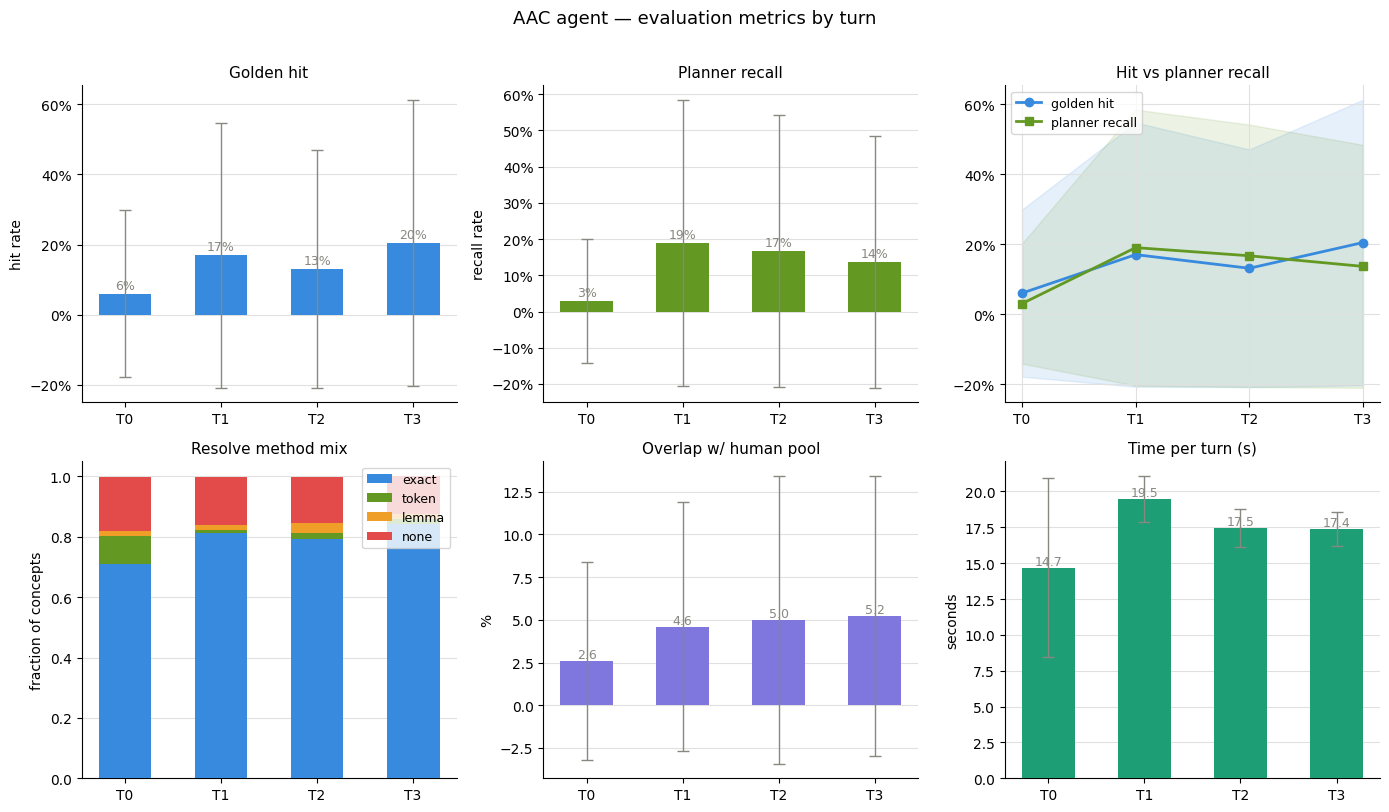

In [8]:
# ── plots ─────────────────────────────────────────────────────────────────────
# Only turns 0-3 are plotted (T4/T5 have n<20 and are statistically unreliable)

VALID_TURNS = [0, 1, 2, 3]
TURN_LABELS = [f"T{t}" for t in VALID_TURNS]

def _turn_vals(metric):
    rows = df_results[df_results["metric"].str.match(rf"^{metric}@turn_\d+$")]
    rows = rows[rows["metric"].apply(lambda m: int(m.split("_")[-1]) in VALID_TURNS)]
    rows = rows.sort_values("metric")
    return rows["mean"].values, rows["std"].values, rows["n"].values

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("AAC agent — evaluation metrics by turn", fontsize=13, fontweight="500", y=1.01)

BLUE   = "#378ADD"
GREEN  = "#639922"
PURPLE = "#7F77DD"
TEAL   = "#1D9E75"
RED    = "#E24B4A"
AMBER  = "#EF9F27"
GRAY   = "#888780"

def _bar(ax, vals, stds, color, ylabel, title, pct=False):
    x = np.arange(len(VALID_TURNS))
    bars = ax.bar(x, vals, color=color, width=0.55, zorder=3)
    ax.errorbar(x, vals, yerr=stds, fmt="none", color=GRAY, capsize=4, linewidth=1, zorder=4)
    ax.set_xticks(x); ax.set_xticklabels(TURN_LABELS)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="500")
    ax.grid(axis="y", color="#e0e0e0", zorder=0)
    ax.spines[["top","right"]].set_visible(False)
    if pct:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1 if vals.max() <= 1 else 100))
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{v:.0%}" if pct and vals.max() <= 1 else f"{v:.1f}",
                ha="center", va="bottom", fontsize=9, color=GRAY)

# 1 — Golden hit by turn
vals, stds, _ = _turn_vals("golden_hit")
_bar(axes[0,0], vals, stds, BLUE, "hit rate", "Golden hit", pct=True)

# 2 — Planner recall by turn
vals, stds, _ = _turn_vals("planner_recall")
_bar(axes[0,1], vals, stds, GREEN, "recall rate", "Planner recall", pct=True)

# 3 — Golden hit vs planner recall overlay (line)
hit_v, hit_s, _ = _turn_vals("golden_hit")
rec_v, rec_s, _ = _turn_vals("planner_recall")
x = np.arange(len(VALID_TURNS))
axes[0,2].plot(x, hit_v, marker="o", color=BLUE,  label="golden hit",     linewidth=2)
axes[0,2].fill_between(x, hit_v-hit_s, hit_v+hit_s, color=BLUE,  alpha=0.12)
axes[0,2].plot(x, rec_v, marker="s", color=GREEN, label="planner recall", linewidth=2)
axes[0,2].fill_between(x, rec_v-rec_s, rec_v+rec_s, color=GREEN, alpha=0.12)
axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(TURN_LABELS)
axes[0,2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0,2].set_title("Hit vs planner recall", fontsize=11, fontweight="500")
axes[0,2].legend(fontsize=9); axes[0,2].grid(color="#e0e0e0"); axes[0,2].spines[["top","right"]].set_visible(False)

# 4 — Resolve method stacked bar
methods = ["exact", "token", "lemma", "none"]
colors  = [BLUE, GREEN, AMBER, RED]
bottoms = np.zeros(len(VALID_TURNS))
for method, color in zip(methods, colors):
    rows = df_results[df_results["metric"].str.match(rf"^resolve_frac_{method}@turn_\d+$")]
    rows = rows[rows["metric"].apply(lambda m: int(m.split("_")[-1]) in VALID_TURNS)].sort_values("metric")
    vals = rows["mean"].values
    axes[1,0].bar(np.arange(len(VALID_TURNS)), vals, bottom=bottoms, color=color, width=0.55, label=method, zorder=3)
    bottoms += vals
axes[1,0].set_xticks(np.arange(len(VALID_TURNS))); axes[1,0].set_xticklabels(TURN_LABELS)
axes[1,0].set_ylabel("fraction of concepts", fontsize=10)
axes[1,0].set_title("Resolve method mix", fontsize=11, fontweight="500")
axes[1,0].legend(fontsize=9, loc="upper right"); axes[1,0].grid(axis="y", color="#e0e0e0", zorder=0)
axes[1,0].spines[["top","right"]].set_visible(False)

# 5 — Overlap with human pool by turn
vals, stds, _ = _turn_vals("overlap_with_human_pool_%")
_bar(axes[1,1], vals, stds, PURPLE, "%", "Overlap w/ human pool")

# 6 — Time per turn
vals, stds, _ = _turn_vals("time_per_turn_s")
_bar(axes[1,2], vals, stds, TEAL, "seconds", "Time per turn (s)")

plt.tight_layout()
plt.savefig("eval_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# ── 4.1 Sentence-level hit classification ──────────────────────────────────

_df = df[df["turn_pos"].isin(VALID_TURNS)].copy()

# Ricalcolo colonne derivate ─ stessa logica della sezione 3
_df["golden_hit"] = _df.apply(
    lambda r: int(r["gold_id"] in r["predicted_ids"]), axis=1
)
# resolve_methods è la lista già parsata (resolve_method è ancora stringa raw)
_df["resolve_frac_exact"] = _df["resolve_methods"].apply(
    lambda ms: ms.count("exact") / len(ms) if ms else np.nan
)
_df["resolve_frac_none"] = _df["resolve_methods"].apply(
    lambda ms: ms.count("none") / len(ms) if ms else np.nan
)
# planner_recall: check binario, stesso calcolo della sezione 3
# (planner_concepts sono stringhe → non confrontabile con candidate_ids che sono interi)
_df["planner_recall"] = _df.apply(
    lambda r: int(
        r["concept_text"].strip().lower() in
        [c.strip().lower() for c in r["planner_concepts"]]
    ),
    axis=1,
)
# gold_reachable: gold_id è nel pool dell'annotatore per questo turno?
_df["gold_reachable"] = _df.apply(
    lambda r: int(r["gold_id"] in r["candidate_ids"]), axis=1
)
# overlap_with_human_pool_%: stesso calcolo della sezione 3
_df["overlap"] = _df.apply(
    lambda r: (
        len(set(r["candidate_ids"]) & set(r["predicted_ids"]))
        / len(r["candidate_ids"]) * 100
        if len(r["candidate_ids"]) > 0 else np.nan
    ),
    axis=1,
)

# Classificazione sentence run
sentence_stats = (
    _df.groupby(["row_idx", "input_type"])
    .agg(
        n_turns        = ("turn_pos", "count"),
        n_hits         = ("golden_hit", "sum"),
        resolve_exact  = ("resolve_frac_exact", "mean"),
        resolve_none   = ("resolve_frac_none", "mean"),
        p_recall       = ("planner_recall", "mean"),
        gold_reachable = ("gold_reachable", "mean"),   # 1.0 = gold raggiungibile in tutti i turni
        overlap        = ("overlap", "mean"),
    )
    .reset_index()
)

def _classify(row):
    if row["n_hits"] == 0:
        return "miss_totale"
    elif row["n_hits"] == row["n_turns"]:
        return "hit_completo"
    else:
        return "hit_parziale"

sentence_stats["outcome"] = sentence_stats.apply(_classify, axis=1)

outcome_counts = sentence_stats["outcome"].value_counts().rename("n_sentences")
print("=== Distribuzione outcome per sentence run ===")
print(outcome_counts.to_string())
print(f"\nTotale sentence runs: {len(sentence_stats)}")

=== Distribuzione outcome per sentence run ===
outcome
miss_totale     61
hit_parziale    36
hit_completo     3

Totale sentence runs: 100


In [10]:
# ── 4.2 Tabella comparativa: miss_totale vs hit_parziale vs hit_completo ───
# Per ogni gruppo: resolve_exact, resolve_none, planner_recall, overlap e gold_reachable.
#
# gold_reachable < 1.0 nei miss_totale → almeno un turno ha il gold fuori dal
# pool dell'annotatore (annotazione inconsistente): quel miss non è imputabile al modello.

comparison = (
    sentence_stats
    .groupby("outcome")[["resolve_exact", "resolve_none", "p_recall", "gold_reachable", "overlap"]]
    .agg(["mean", "std", "count"])
    .round(3)
)

comparison.columns = ["_".join(c) for c in comparison.columns]

print("=== Metriche medie per outcome ===")
print(comparison.to_string())

summary_table = (
    sentence_stats
    .groupby("outcome")
    .agg(
        n              = ("outcome", "count"),
        resolve_exact  = ("resolve_exact", "mean"),
        resolve_none   = ("resolve_none", "mean"),
        planner_recall = ("p_recall", "mean"),
        gold_reachable = ("gold_reachable", "mean"),
        overlap        = ("overlap", "mean"),
    )
    .round(3)
)
print("\n=== Tabella riassuntiva ===")
print(summary_table.to_string())

=== Metriche medie per outcome ===
              resolve_exact_mean  resolve_exact_std  resolve_exact_count  resolve_none_mean  resolve_none_std  resolve_none_count  p_recall_mean  p_recall_std  p_recall_count  gold_reachable_mean  gold_reachable_std  gold_reachable_count  overlap_mean  overlap_std  overlap_count
outcome                                                                                                                                                                                                                                                                                
hit_completo               0.903              0.112                    3              0.045             0.039                   3          0.000          0.00               3                  1.0                 0.0                     3        16.667        2.887              3
hit_parziale               0.807              0.144                   36              0.127             0.101                

## 5. Ground-truth Quality Audit

Queste celle servono a diagnosticare se gli errori sono del **modello** o del **dataset**  
(gold inconsistenti, pool di candidati sbagliati, annotazioni rumorose).  

| Cella | Cosa fa |
|-------|---------|
| 5.1 | Top-20 frasi più sbagliate — mostra gold / candidati / predetti per ogni concetto |
| 5.2 | Plotta pittogrammi da lista di ID usando le PNG locali (debug visivo) |
| 5.3 | Mostra metadata pittogrammi da lista di ID (keywords, categorie, tag, flag AAC) |

In [24]:
# ── 5.1  Top-20 frasi più sbagliate (≈ 30%) ───────────────────────────────
# Per ogni frase mostra, per ciascun concetto:
#   • gold_id       — il pittogramma atteso dall'annotatore
#   • candidate_ids — il pool umano (~10 pittogrammi)
#   • predicted_ids — la finestra ranked del modello
#   • hit           — ✓ se gold è nella finestra, ✗ se no
#
# OBIETTIVO: capire se il miss è un vero errore del modello
#            o un problema di gold/candidati sbagliati.

import ast, json
import pandas as pd

# Ricostruisci golden_hit per riga (in caso non ci sia già)
df["hit"] = df.apply(
    lambda r: int(r["gold_id"]) in r["predicted_ids"], axis=1
).astype(int)

# Aggrega per (row_idx, input_type): hit medio della frase
sentence_hit = (
    df.groupby(["row_idx", "input_type"])["hit"]
    .mean()
    .reset_index()
    .rename(columns={"hit": "sentence_hit"})
)

# Top-20 frasi con il mean-hit più basso
TOP_N = 20
worst = (
    sentence_hit
    .sort_values("sentence_hit")
    .head(TOP_N)
)

print(f"Top-{TOP_N} frasi più sbagliate  "
      f"(su {len(sentence_hit)} frasi totali, "
      f"≈{TOP_N/len(sentence_hit)*100:.0f}%):\n")

for _, row in worst.iterrows():
    ridx  = row["row_idx"]
    itype = row["input_type"]
    smean = row["sentence_hit"]

    turns = df[(df["row_idx"] == ridx) & (df["input_type"] == itype)].sort_values("hit").copy()

    print("═" * 80)
    print(f"row_idx={ridx}  input_type={itype}  golden_hit(sentence)={smean:.2f}")
    print("═" * 80)

    for _, t in turns.iterrows():
        hit_flag = "✓ HIT " if t["hit"] else "✗ MISS"
        print(f"\n  [{hit_flag}]  turn_pos={t['turn_pos']}  concept: «{t['concept_text']}»")
        print(f"    gold_id       : {t['gold_id']}")
        print(f"    candidate_ids : {t['candidate_ids']}")
        predicted_preview = t['predicted_ids'][:10]
        ellipsis = '...' if len(t['predicted_ids']) > 10 else ''
        print(f"    predicted_ids : {predicted_preview}{ellipsis}")
    print()

Top-20 frasi più sbagliate  (su 100 frasi totali, ≈20%):

════════════════════════════════════════════════════════════════════════════════
row_idx=196  input_type=vague  golden_hit(sentence)=0.00
════════════════════════════════════════════════════════════════════════════════

  [✗ MISS]  turn_pos=0  concept: «I»
    gold_id       : 8128
    candidate_ids : [np.int64(9851), np.int64(25133), np.int64(6955), np.int64(5946), np.int64(6071), np.int64(17054), np.int64(6155), np.int64(8128), np.int64(38170), np.int64(8643)]
    predicted_ids : [25062, 11251, 11263, 37822, 6624, 22147, 2599, 26152, 26153, 26154]...

  [✗ MISS]  turn_pos=1  concept: «work»
    gold_id       : 27403
    candidate_ids : [np.int64(9851), np.int64(38170), np.int64(29112), np.int64(16089), np.int64(37554), np.int64(11262), np.int64(2921), np.int64(27403), np.int64(16182), np.int64(29114)]
    predicted_ids : [25062, 11251, 11263, 37822, 24863, 32212, 38914, 8008, 6624, 22147]...

  [✗ MISS]  turn_pos=2  concept: «h

row_idx=1347  input_type=clear  concept=«I»

  gold_id       : 9851
  candidate_ids : [np.int64(9851), np.int64(8643), np.int64(25133), np.int64(6155), np.int64(6955), np.int64(17054), np.int64(5946), np.int64(6071), np.int64(30991), np.int64(7179)]
  predicted_ids : [30116, 30117, 30118, 30119, 30120, 22631, 27385, 28599, 34565, 39792]



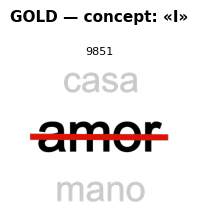

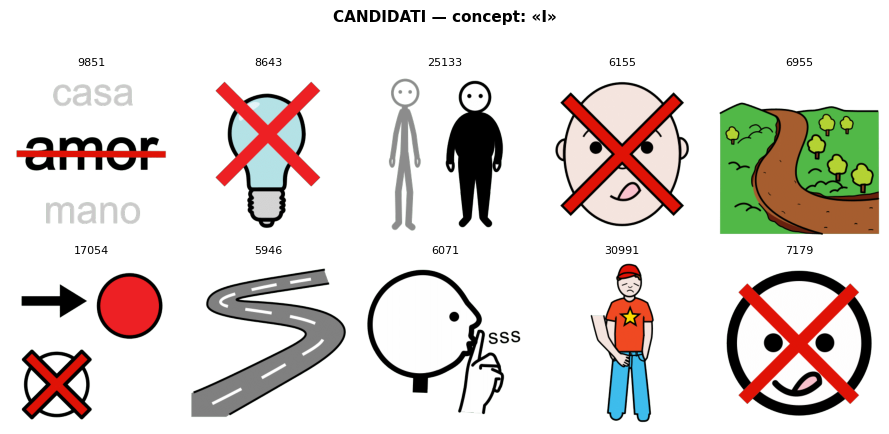

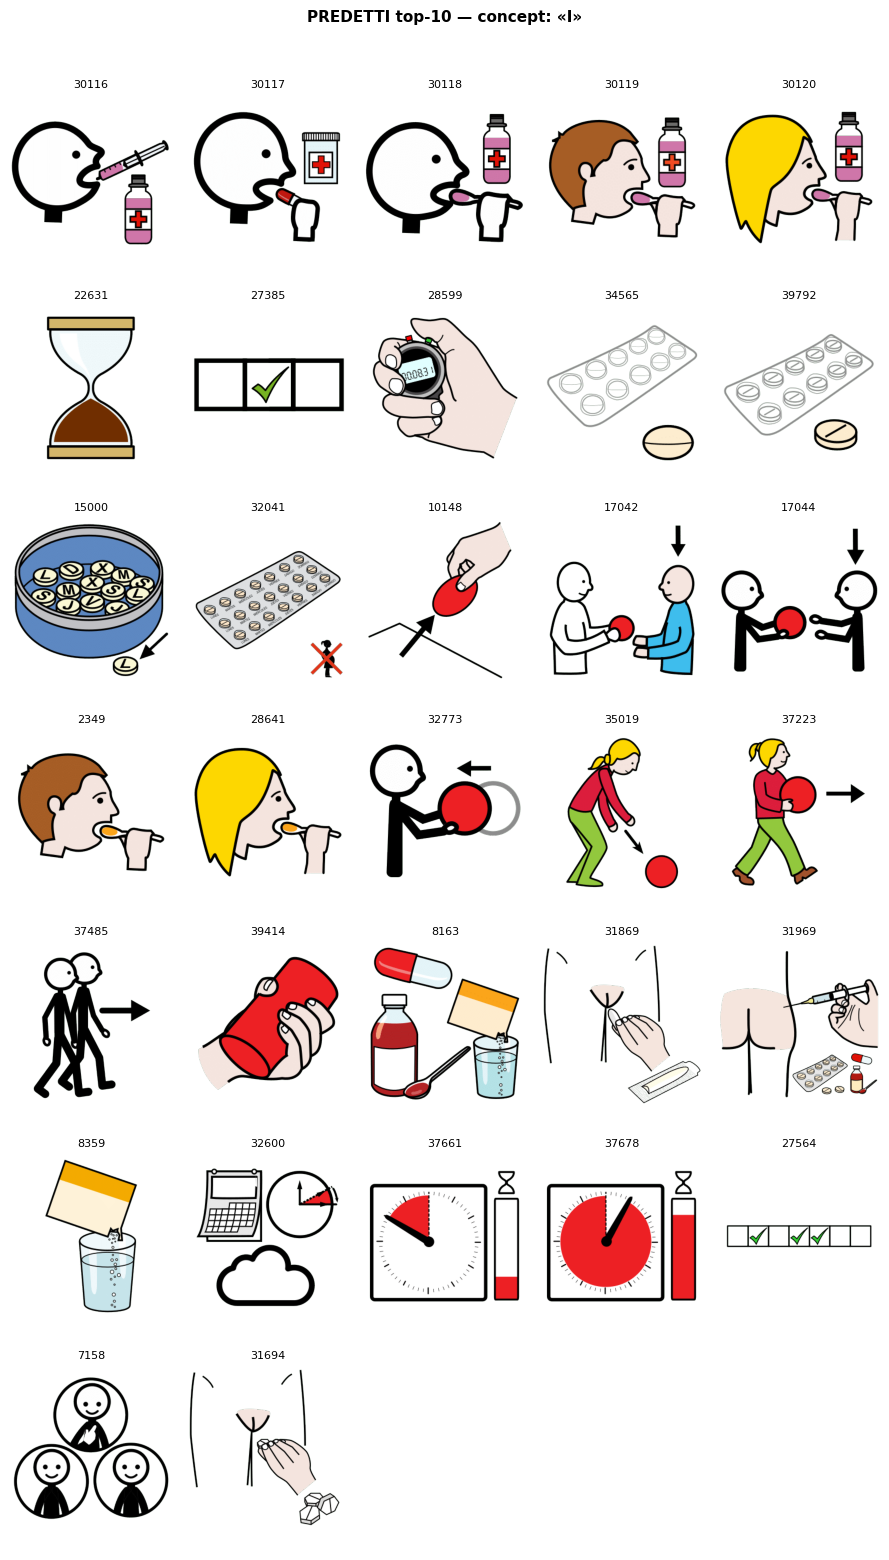

In [23]:
# ── 5.2  Plotta pittogrammi da lista di ID ────────────────────────────────
# Usa le immagini PNG locali in  app/datasets/pictograms/{id}.png
# Chiamata tipica:
#
#   plot_pictograms([5556, 37810, 36717], title="Candidati frase X")
#
# o per debuggare una riga specifica del dataframe:
#
#   row = df[df["row_idx"]==1125].iloc[0]
#   plot_pictograms([row["gold_id"]] + list(row["candidate_ids"]),
#                   title=f"gold + candidati — concept: {row['concept_text']}")

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# DOPO (ARASAAC CDN)
import requests
from io import BytesIO
from PIL import Image

ARASAAC_CDN = "https://static.arasaac.org/pictograms/{id}/{id}_300.png"

def plot_pictograms(ids, cols=5, title=None, figsize_per_cell=(1.8, 2.2)):
    ids = [int(i) for i in ids]
    n = len(ids)
    if n == 0:
        print("Lista vuota.")
        return

    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols,
                             figsize=(figsize_per_cell[0]*cols, figsize_per_cell[1]*rows),
                             squeeze=False)
    flat_axes = axes.flatten()
    if title:
        fig.suptitle(title, fontsize=11, fontweight="bold", y=1.01)

    for ax, pid in zip(flat_axes, ids):
        try:
            resp = requests.get(ARASAAC_CDN.format(id=pid), timeout=5)
            resp.raise_for_status()
            img = Image.open(BytesIO(resp.content))
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, f"ID {pid}\n({type(e).__name__})",
                    ha="center", va="center", fontsize=8, color="gray",
                    transform=ax.transAxes)
            ax.set_facecolor("#f0f0f0")
        ax.set_title(str(pid), fontsize=8)
        ax.axis("off")

    for ax in flat_axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# ── Esempio: prima riga più sbagliata del dataframe ───────────────────────
worst_row = df.sort_values("hit").iloc[1]

print(f"row_idx={worst_row['row_idx']}  "
      f"input_type={worst_row['input_type']}  "
      f"concept=«{worst_row['concept_text']}»\n")
print(f"  gold_id       : {worst_row['gold_id']}")
print(f"  candidate_ids : {list(worst_row['candidate_ids'])[:10]}")
print(f"  predicted_ids : {worst_row['predicted_ids'][:10]}\n")

# 1) Il gold
plot_pictograms(
    [worst_row["gold_id"]],
    cols=1,
    title=f"GOLD — concept: «{worst_row['concept_text']}»"
)

# 2) Il pool dei candidati
plot_pictograms(
    list(worst_row["candidate_ids"])[:10],
    cols=5,
    title=f"CANDIDATI — concept: «{worst_row['concept_text']}»"
)

# 3) I predetti dal modello (top-10)
plot_pictograms(
    worst_row["predicted_ids"],
    cols=5,
    title=f"PREDETTI top-10 — concept: «{worst_row['concept_text']}»"
)

In [13]:
# ── 5.3  Metadata pittogrammi da lista di ID ──────────────────────────────
# Carica il JSON locale dei metadata e restituisce un DataFrame.
# Utile per controllare se il gold ha le stesse categorie/tag dei candidati,
# se è marcato come AAC-friendly, ecc.
#
# Chiamata tipica:
#
#   meta_df = get_pictogram_metadata([5556, 37810, 36717])
#   display(meta_df)

import json
import pandas as pd

PICTOGRAM_JSON = PROJECT_ROOT / "app" / "datasets" / "en" / "pictograms.json"

# Carica una volta sola (lazy, variabile module-level)
if "_pict_meta" not in dir():
    with open(PICTOGRAM_JSON) as _f:
        _pict_meta = json.load(_f)
    print(f"Caricati metadata per {len(_pict_meta)} pittogrammi.")


def get_pictogram_metadata(ids, lang_json=None):
    """
    Restituisce un DataFrame con i metadata dei pittogrammi richiesti.

    Parameters
    ----------
    ids : list[int | str]
        Lista di ID pittogramma.
    lang_json : dict | None
        Dizionario {id_str → record} già caricato.
        Se None usa _pict_meta (dataset EN già caricato sopra).

    Returns
    -------
    pd.DataFrame con colonne:
        id, keyword, synonyms, categories, tags, synsets,
        aac, aac_color, sex, violence, schematic, skin, hair,
        created, last_updated
    """
    if lang_json is None:
        lang_json = _pict_meta

    records = []
    for pid in ids:
        key = str(int(pid))
        rec = lang_json.get(key)
        if rec is None:
            records.append({"id": int(pid), "keyword": "NOT FOUND"})
            continue

        kws      = rec.get("keywords", [])
        primary  = kws[0]["keyword"] if kws else None
        synonyms = [k["keyword"] for k in kws[1:]] if len(kws) > 1 else []

        records.append({
            "id"          : rec.get("id", int(pid)),
            "keyword"     : primary,
            "synonyms"    : synonyms,
            "categories"  : rec.get("categories", []),
            "tags"        : rec.get("tags", []),
            "synsets"     : rec.get("synsets", []),
            "aac"         : rec.get("aac", None),
            "aac_color"   : rec.get("aac_color", None),
            "sex"         : rec.get("sex", None),
            "violence"    : rec.get("violence", None),
            "schematic"   : rec.get("schematic", None),
            "skin"        : rec.get("skin", None),
            "hair"        : rec.get("hair", None),
            "created"     : rec.get("created", None),
            "last_updated": rec.get("last_updated", None),
        })

    return pd.DataFrame(records).set_index("id")


# ── Esempio: stessa riga peggiore di prima ────────────────────────────────
worst_row = df.sort_values("hit").iloc[0]

probe_ids = list(dict.fromkeys(
    [worst_row["gold_id"]] + list(worst_row["candidate_ids"])[:9]
))

meta_df = get_pictogram_metadata(probe_ids)

print(f"\nMetadata per concept «{worst_row['concept_text']}»  "
      f"(gold={worst_row['gold_id']}, + top candidati)\n")

display(meta_df[["keyword", "synonyms", "categories", "tags",
                 "synsets", "aac", "aac_color"]])

# ── Versione compatta solo keyword+categories per confronto rapido ────────
print("\n── Confronto rapido keyword / categories ──")
for pid, row in meta_df.iterrows():
    marker = " ← GOLD" if pid == int(worst_row["gold_id"]) else ""
    print(f"  {pid:>6}  {row['keyword']:<25}  {row['categories']}{marker}")

Caricati metadata per 13780 pittogrammi.

Metadata per concept «grey»  (gold=8122, + top candidati)



,keyword,synonyms,categories,tags,synsets,aac,aac_color
id,,,,,,,
8122,waterproof,[raincoat],"[clothes, core vocabulary-object, fashion]","[object, fashion, clothes, core vocabulary]",[04056517-n],True,True
9851,the word is missing,[I don´t know the word],[expression],"[communication, language, expression]",[],False,False
8643,darkness,[],[miscellaneous],[],[14007000-n],False,False
17054,other,[another],[indefinite adjective],"[communication, language, adjective, indefinit...","[02076759-a, 02077592-s]",False,False
10742,darkness,[],[miscellaneous],[],"[08663881-n, 14007000-n]",False,False
6155,dislike,"[take against, I do not like that, I do not li...","[verb, senses, food]","[communication, language, verb, human body, ph...","[07516784-n, 01780648-v, 01821097-v, 01806732-a]",False,False
36746,NY,[],[letter],"[communication, language, alphabet, letter]",[],False,False
7148,rain,[],"[verb, atmospheric phenomena, core vocabulary-...","[communication, language, verb, meteorology, a...",[02762516-v],True,False
25133,fat,"[obese, plump, chubby]","[qualifying adjective, physical features, diet...","[communication, language, adjective, qualifyin...","[00989218-a, 00990368-s, 00989957-s]",True,False



── Confronto rapido keyword / categories ──
    8122  waterproof                 ['clothes', 'core vocabulary-object', 'fashion'] ← GOLD
    9851  the word is missing        ['expression']
    8643  darkness                   ['miscellaneous']
   17054  other                      ['indefinite adjective']
   10742  darkness                   ['miscellaneous']
    6155  dislike                    ['verb', 'senses', 'food']
   36746  NY                         ['letter']
    7148  rain                       ['verb', 'atmospheric phenomena', 'core vocabulary-communication', 'core vocabulary-knowledge']
   25133  fat                        ['qualifying adjective', 'physical features', 'dietetics', 'core vocabulary-communication', 'core vocabulary-living being', 'core vocabulary-knowledge']


In [14]:
# ── 4.3 Verifica ipotesi: miss_totale ha resolve_exact < altri? ────────────
# Test di Mann-Whitney U (non parametrico, adatto a distribuzioni skewed)

from scipy import stats

miss    = sentence_stats[sentence_stats["outcome"] == "miss_totale"]
nonmiss = sentence_stats[sentence_stats["outcome"] != "miss_totale"]

for metric, label in [
    ("resolve_exact", "resolve_exact (miss < non-miss?)"),
    ("resolve_none",  "resolve_none  (miss > non-miss?)"),
    ("p_recall",      "planner_recall (miss < non-miss?)"),
]:
    u, p = stats.mannwhitneyu(
        miss[metric].dropna(),
        nonmiss[metric].dropna(),
        alternative="less" if "none" not in metric else "greater"
    )
    direction = "↓ miss < non-miss" if "none" not in metric else "↑ miss > non-miss"
    sig = "**" if p < 0.05 else ("~" if p < 0.10 else "ns")
    print(f"{label}")
    print(f"  U={u:.0f}  p={p:.4f}  {sig}  {direction}\n")

# Nota: con dataset piccolo il test ha poca potenza —
# guardare le medie in 4.2 è spesso più informativo del p-value

resolve_exact (miss < non-miss?)
  U=906  p=0.0227  **  ↓ miss < non-miss

resolve_none  (miss > non-miss?)
  U=1530  p=0.0080  **  ↑ miss > non-miss

planner_recall (miss < non-miss?)
  U=876  p=0.0045  **  ↓ miss < non-miss



/var/folders/n9/r8x6svc56fjb_2b7zb4tztr80000gn/T/ipykernel_1668/43087258.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(outcomes, rotation=15, ha="right", fontsize=8)
/var/folders/n9/r8x6svc56fjb_2b7zb4tztr80000gn/T/ipykernel_1668/43087258.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(outcomes, rotation=15, ha="right", fontsize=8)
/var/folders/n9/r8x6svc56fjb_2b7zb4tztr80000gn/T/ipykernel_1668/43087258.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(outcomes, rotation=15, ha="right", fontsize=8)


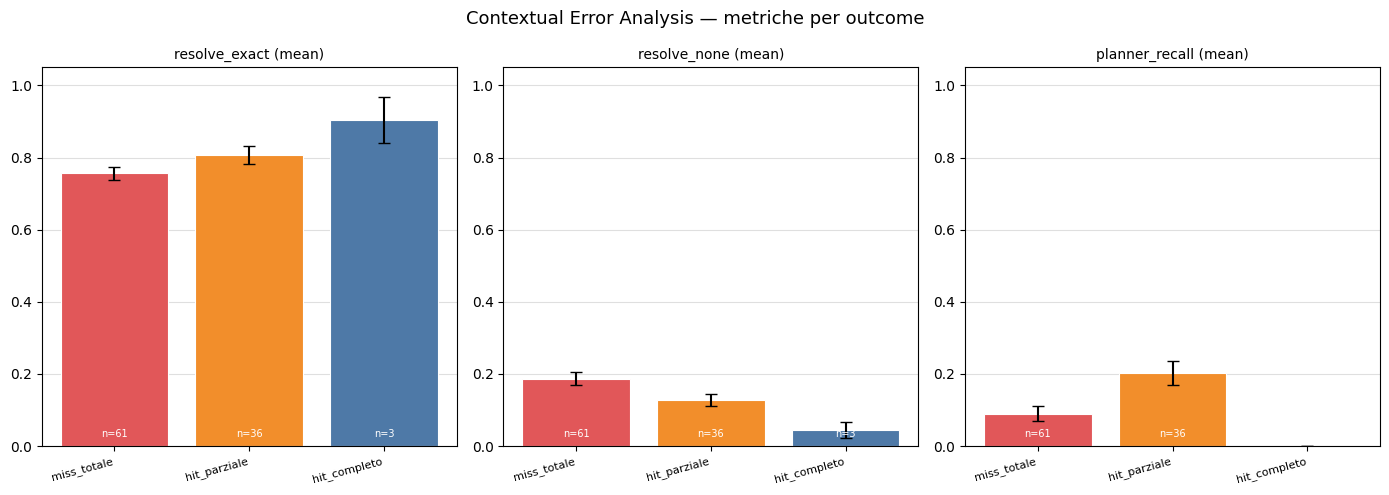

In [15]:
# ── 4.4 Plot: distribuzione resolve/recall per outcome ─────────────────────

import matplotlib.pyplot as plt
import numpy as np

outcomes   = ["miss_totale", "hit_parziale", "hit_completo"]
palette    = {"miss_totale": "#e15759", "hit_parziale": "#f28e2b", "hit_completo": "#4e79a7"}
metrics    = ["resolve_exact", "resolve_none", "p_recall"]
m_labels   = ["resolve_exact (mean)", "resolve_none (mean)", "planner_recall (mean)"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
fig.suptitle("Contextual Error Analysis — metriche per outcome", fontsize=13)

for ax, metric, mlabel in zip(axes, metrics, m_labels):
    data   = [sentence_stats[sentence_stats["outcome"] == o][metric].dropna() for o in outcomes]
    means  = [d.mean() for d in data]
    sems   = [d.std() / np.sqrt(len(d)) if len(d) > 1 else 0 for d in data]
    colors = [palette[o] for o in outcomes]

    bars = ax.bar(outcomes, means, yerr=sems, color=colors,
                  capsize=4, edgecolor="white", linewidth=0.8)
    ax.set_title(mlabel, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(outcomes, rotation=15, ha="right", fontsize=8)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

    # Annota n per ogni barra
    for bar, d in zip(bars, data):
        ax.text(bar.get_x() + bar.get_width() / 2, 0.02,
                f"n={len(d)}", ha="center", va="bottom", fontsize=7, color="white")

plt.tight_layout()
plt.savefig("contextual_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# ── 4.5 Raggiungibilità del gold nei miss_totale ───────────────────────────
# Separa gli errori "obbligati" (gold ∉ candidate_ids → annotazione inconsistente)
# dagli errori reali del modello (gold ∈ candidate_ids ma non trovato nella window).

miss = sentence_stats[sentence_stats["outcome"] == "miss_totale"]

# gold_reachable per sentence run: media tra i turni → 1.0 solo se tutti raggiungibili
miss_bad_gold  = (miss["gold_reachable"] < 1.0).sum()
miss_good_gold = (miss["gold_reachable"] == 1.0).sum()

print("=== Raggiungibilità del gold nei miss_totale ===")
print(f"  miss_totale totali                       : {len(miss)}")
print(f"  gold ∉ candidate_ids (almeno 1 turno)    : {miss_bad_gold}  ({miss_bad_gold/len(miss):.0%})")
print(f"  gold ∈ candidate_ids (tutti i turni)     : {miss_good_gold}  ({miss_good_gold/len(miss):.0%})")
print()

# Tra i miss con gold sempre raggiungibile: quanto overlap con il pool umano?
miss_reachable = miss[miss["gold_reachable"] == 1.0]
if len(miss_reachable) > 0:
    print("=== Overlap w/ human pool per miss_totale con gold raggiungibile ===")
    print(f"  overlap medio : {miss_reachable['overlap'].mean():.1f}%  (std={miss_reachable['overlap'].std():.1f})")
    print()
    print("  overlap alto + miss → il modello trova il pool giusto")
    print("  ma sceglie un pittogramma diverso da quello scelto dall'annotatore")

=== Raggiungibilità del gold nei miss_totale ===
  miss_totale totali                       : 61
  gold ∉ candidate_ids (almeno 1 turno)    : 0  (0%)
  gold ∈ candidate_ids (tutti i turni)     : 61  (100%)

=== Overlap w/ human pool per miss_totale con gold raggiungibile ===
  overlap medio : 2.6%  (std=3.9)

  overlap alto + miss → il modello trova il pool giusto
  ma sceglie un pittogramma diverso da quello scelto dall'annotatore


In [17]:
# ── 4.6 Distribuzione input_type per outcome ───────────────────────────────
# Verifica se il tasso di miss_totale differisce tra frasi clear e vague.

ct = (
    sentence_stats
    .groupby(["outcome", "input_type"])
    .size()
    .unstack(fill_value=0)
)
ct["totale"] = ct.sum(axis=1)
if "clear" in ct.columns:
    ct["clear_%"] = (ct["clear"] / ct["totale"] * 100).round(1)
if "vague" in ct.columns:
    ct["vague_%"] = (ct["vague"] / ct["totale"] * 100).round(1)

print("=== Distribuzione input_type per outcome ===")
print(ct.to_string())

=== Distribuzione input_type per outcome ===
input_type    clear  vague  totale  clear_%  vague_%
outcome                                             
hit_completo      2      1       3     66.7     33.3
hit_parziale     20     16      36     55.6     44.4
miss_totale      28     33      61     45.9     54.1
